In [1]:



import pandas as pd

#esercizio 0
# 1. Carica il file (usa r'' per evitare errori di percorso su Windows)
path = r'c:\Users\alfre\OneDrive\Desktop\Big Data\Archive\data\symbol_info_3-25.csv'

df = pd.read_csv(path)


totale_iniziale = len(df)

# 2. Mantieni solo le aziende attive (is_actively_trading == 1)
df_clean = df[df['is_actively_trading'] == 1].copy()

# 3. Rimuovi ETF (is_etf == 0) e Fondi (is_fund == 0)
df_clean = df_clean[df_clean['is_etf'] == 0].copy()
df_clean = df_clean[df_clean['is_fund'] == 0].copy()

# 4. Filtra per il tuo settore assegnato
my_sector = 'Financial Services' 
df_sector = df_clean[df_clean['sector'] == my_sector]

# Verifica il risultato
print(f"Settore selezionato: {my_sector}")
print(f"Numero di aziende nel data set non pulito: {totale_iniziale}")
print(f"Numero di aziende trovate in tutti i settori: {len(df_clean)}")
print(f"Numero di aziende trovate: {len(df_sector)}")
print(df_sector[['symbol', 'company_name', 'sector']].head())


Settore selezionato: Financial Services
Numero di aziende nel data set non pulito: 1000
Numero di aziende trovate in tutti i settori: 999
Numero di aziende trovate: 151
   symbol                 company_name              sector
7   BRK-A      Berkshire Hathaway Inc.  Financial Services
8   BRK-B  Berkshire Hathaway Inc. New  Financial Services
14    JPM        JP Morgan Chase & Co.  Financial Services
15      V                    Visa Inc.  Financial Services
17     MA      Mastercard Incorporated  Financial Services


In [2]:
#ESERCIZIO 1

#first we compute the mean and the median


media_mc = df_sector['market_cap'].mean()
mediana_mc = df_sector['market_cap'].median()

#let's make a control
print(f"La media è: {media_mc}")
print(f"La mediana è: {mediana_mc}")

La media è: 69564720205.98676
La mediana è: 22018596864.0


COMMENT ON MEAN VS MEDIAN:
In the Financial Services sector, the mean market capitalization is significantly higher than the median. 
This indicates a strongly right-skewed distribution. The market is populated by a large number of 
small-to-medium financial firms, alongside a few massive industry giants (e.g., major banks or payment processors). 
These few outliers pull the mean up, making the median a much more accurate representation of the "typical" 
company size in this sector.

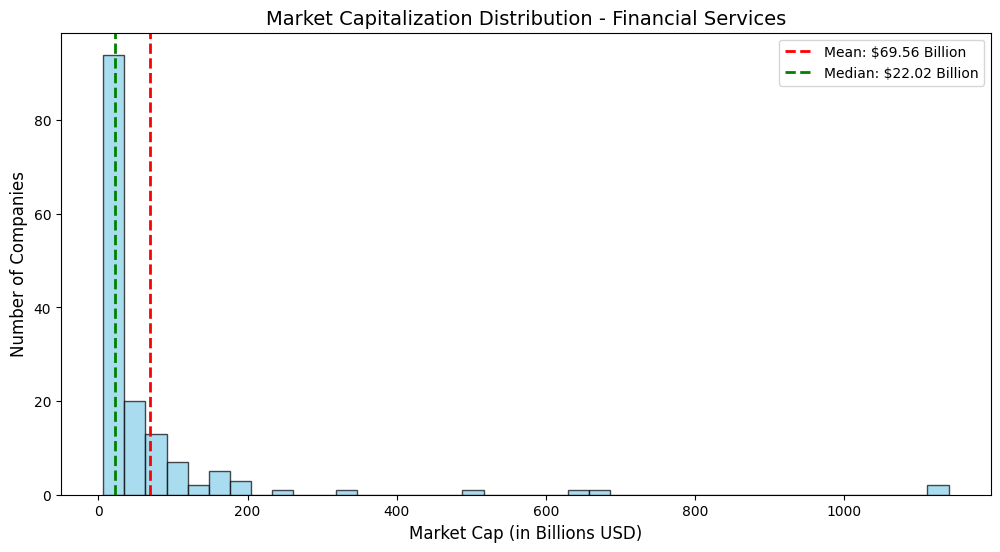

In [3]:
import matplotlib.pyplot as plt

# --- PLOTTING THE HISTOGRAM ---

# To make the x-axis readable, we divide the market cap by 1 billion (1e9)
market_cap_billions = df_sector['market_cap'] / 1e9
mean_bn = media_mc / 1e9
median_bn = mediana_mc / 1e9

# Create the figure
plt.figure(figsize=(12, 6))

# Plot the histogram
# We use 40 bins to get a good granularity of the distribution
plt.hist(market_cap_billions, bins=40, color='skyblue', edgecolor='black', alpha=0.7)

# Add the vertical line for the MEAN (Red)
plt.axvline(mean_bn, color='red', linestyle='dashed', linewidth=2, 
            label=f'Mean: ${mean_bn:.2f} Billion')

# Add the vertical line for the MEDIAN (Green)
plt.axvline(median_bn, color='green', linestyle='dashed', linewidth=2, 
            label=f'Median: ${median_bn:.2f} Billion')

# Add Titles and Labels
plt.title('Market Capitalization Distribution - Financial Services', fontsize=14)
plt.xlabel('Market Cap (in Billions USD)', fontsize=12)
plt.ylabel('Number of Companies', fontsize=12)

# Show the legend which contains our annotations
plt.legend()

# Display the plot
plt.show()

STATISTICAL VERIFICATION:
The summary statistics generated via the .describe() method confirm the accuracy of our previous calculations. 
Specifically, after adjusting the scale to billions:
1. The calculated Mean perfectly matches the 'mean' value in the summary table.
2. The calculated Median perfectly matches the 50th percentile ('50%') in the summary table.

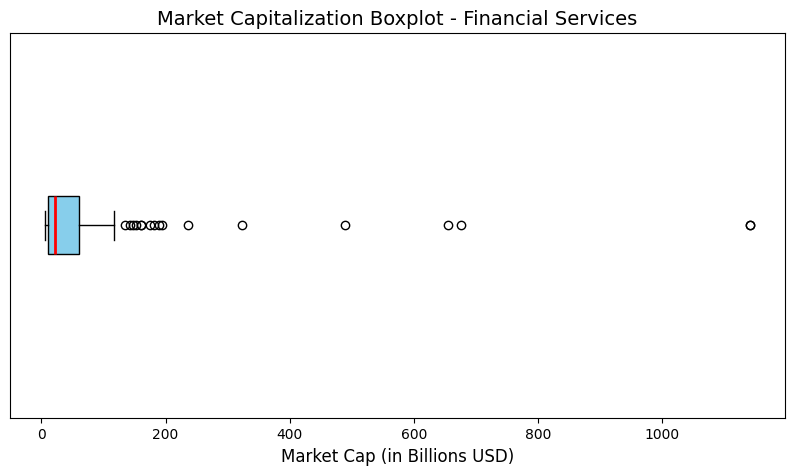

Aziende rimosse (> 300B): 6
Aziende rimanenti: 145


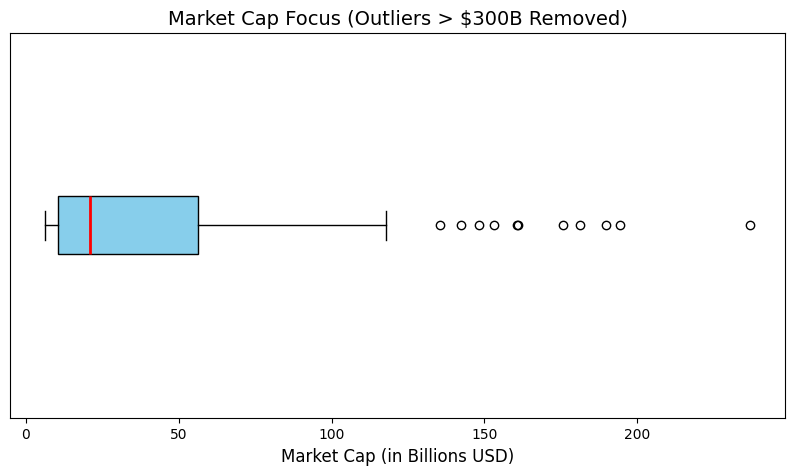

In [4]:
# --- ESERCIZIO 2: OUTLIER DETECTION (BOXPLOT) ---


# Creiamo la figura per il grafico
plt.figure(figsize=(10, 5))

#I chose (10, 5) because for a single horizontal boxplot we don't need an image that's too tall, but we do need it to be wide enough to fit the billions axis.

# Let's create the horizontal boxplot (vert=False)
plt.boxplot(market_cap_billions, vert=False, patch_artist=True, 
            boxprops=dict(facecolor='skyblue', color='black'),
            medianprops=dict(color='red', linewidth=2))

# Let's add titles and labels
plt.title('Market Capitalization Boxplot - Financial Services', fontsize=14)
plt.xlabel('Market Cap (in Billions USD)', fontsize=12)
# Let's remove the numbers on the Y-axis and put the sector name
plt.yticks([]) 

# Let's show the graph
plt.show()

# From the previous boxplot, we can clearly see that the 
#vast majority of the sector is concentrated under $300 billion. Above that, all cases are exceptional
billion_threshold = 300
limite = billion_threshold * 1e9 

# Let's create the clean dataset
df_no_outliers = df_sector[df_sector['market_cap'] <= limite].copy()

# Let's print the report
print(f"Aziende rimosse (> {billion_threshold}B): {len(df_sector) - len(df_no_outliers)}")
print(f"Aziende rimanenti: {len(df_no_outliers)}")

# Let's draw the new Boxplot
plt.figure(figsize=(10, 5))
plt.boxplot(df_no_outliers['market_cap'] / 1e9, vert=False, patch_artist=True, 
            boxprops=dict(facecolor='skyblue', color='black'),
            medianprops=dict(color='red', linewidth=2))

plt.title('Market Cap Focus (Outliers > $300B Removed)', fontsize=14)
plt.xlabel('Market Cap (in Billions USD)', fontsize=12)
plt.yticks([]) 

plt.show()

COMMENT ON OUTLIER REMOVAL:
Based on the visual inspection of the initial boxplot, the sector exhibits extreme right-skewness 
due to a few mega-cap financial institutions. To prevent these giants from skewing the industry 
averages in the following steps, I set a manual threshold of $300 Billion. 
Companies above this threshold are considered outliers for the purpose of this analysis and have been removed. 
From this point forward, 'df_no_outliers' will be used.

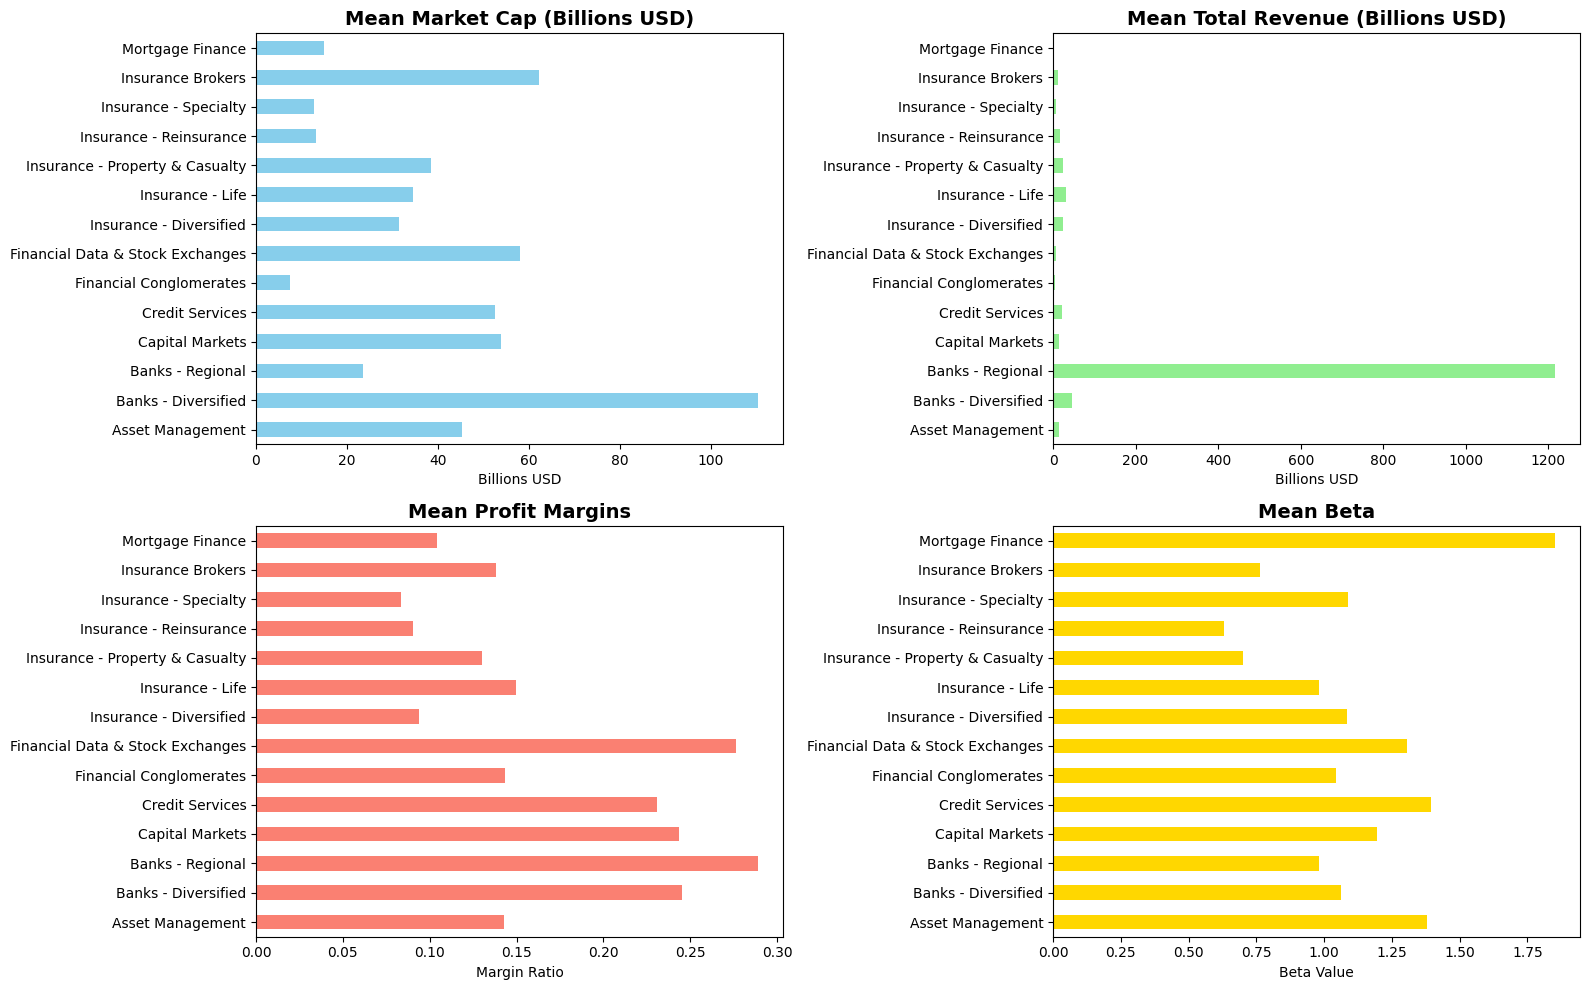

In [5]:
# --- ESERCIZIO 3: INDUSTRY COMPARISON ---

# 1. We group by 'industry' and calculate the average for the 4 metrics
# Note: We use df_no_outliers, the clean dataset from Point 2!
metrics = ['market_cap', 'total_revenue', 'profit_margins', 'beta']
industry_means = df_no_outliers.groupby('industry')[metrics].mean()

# 2. Let's create the basic figure with 4 sub-charts (2 rows x 2 columns)
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 10))

# 3. Let's draw the 4 horizontal bar graphs (.plot(kind='barh'))
# We use sort_values() to sort them from smallest to largest

# Top Left Chart [Row 0, Column 0]: Market Cap (in billions)
(industry_means['market_cap'] / 1e9).plot(kind='barh', ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Mean Market Cap (Billions USD)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Billions USD')
axes[0, 0].set_ylabel('') # I'm removing the "industry" wording for visual cleanliness.

# Top right chart [Row 0, Column 1]: Total Revenue (in billions)
(industry_means['total_revenue'] / 1e9).plot(kind='barh', ax=axes[0, 1], color='lightgreen')
axes[0, 1].set_title('Mean Total Revenue (Billions USD)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Billions USD')
axes[0, 1].set_ylabel('')

# Bottom left chart [Row 1, Column 0]: Profit Margins
industry_means['profit_margins'].plot(kind='barh', ax=axes[1, 0], color='salmon')
axes[1, 0].set_title('Mean Profit Margins', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Margin Ratio')
axes[1, 0].set_ylabel('')

# Bottom right graph [Row 1, Column 1]: Beta
industry_means['beta'].plot(kind='barh', ax=axes[1, 1], color='gold')
axes[1, 1].set_title('Mean Beta', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Beta Value')
axes[1, 1].set_ylabel('')

# This feature prevents the text on one graph from overlapping another.
plt.tight_layout()

#Let's show the final result
plt.show()

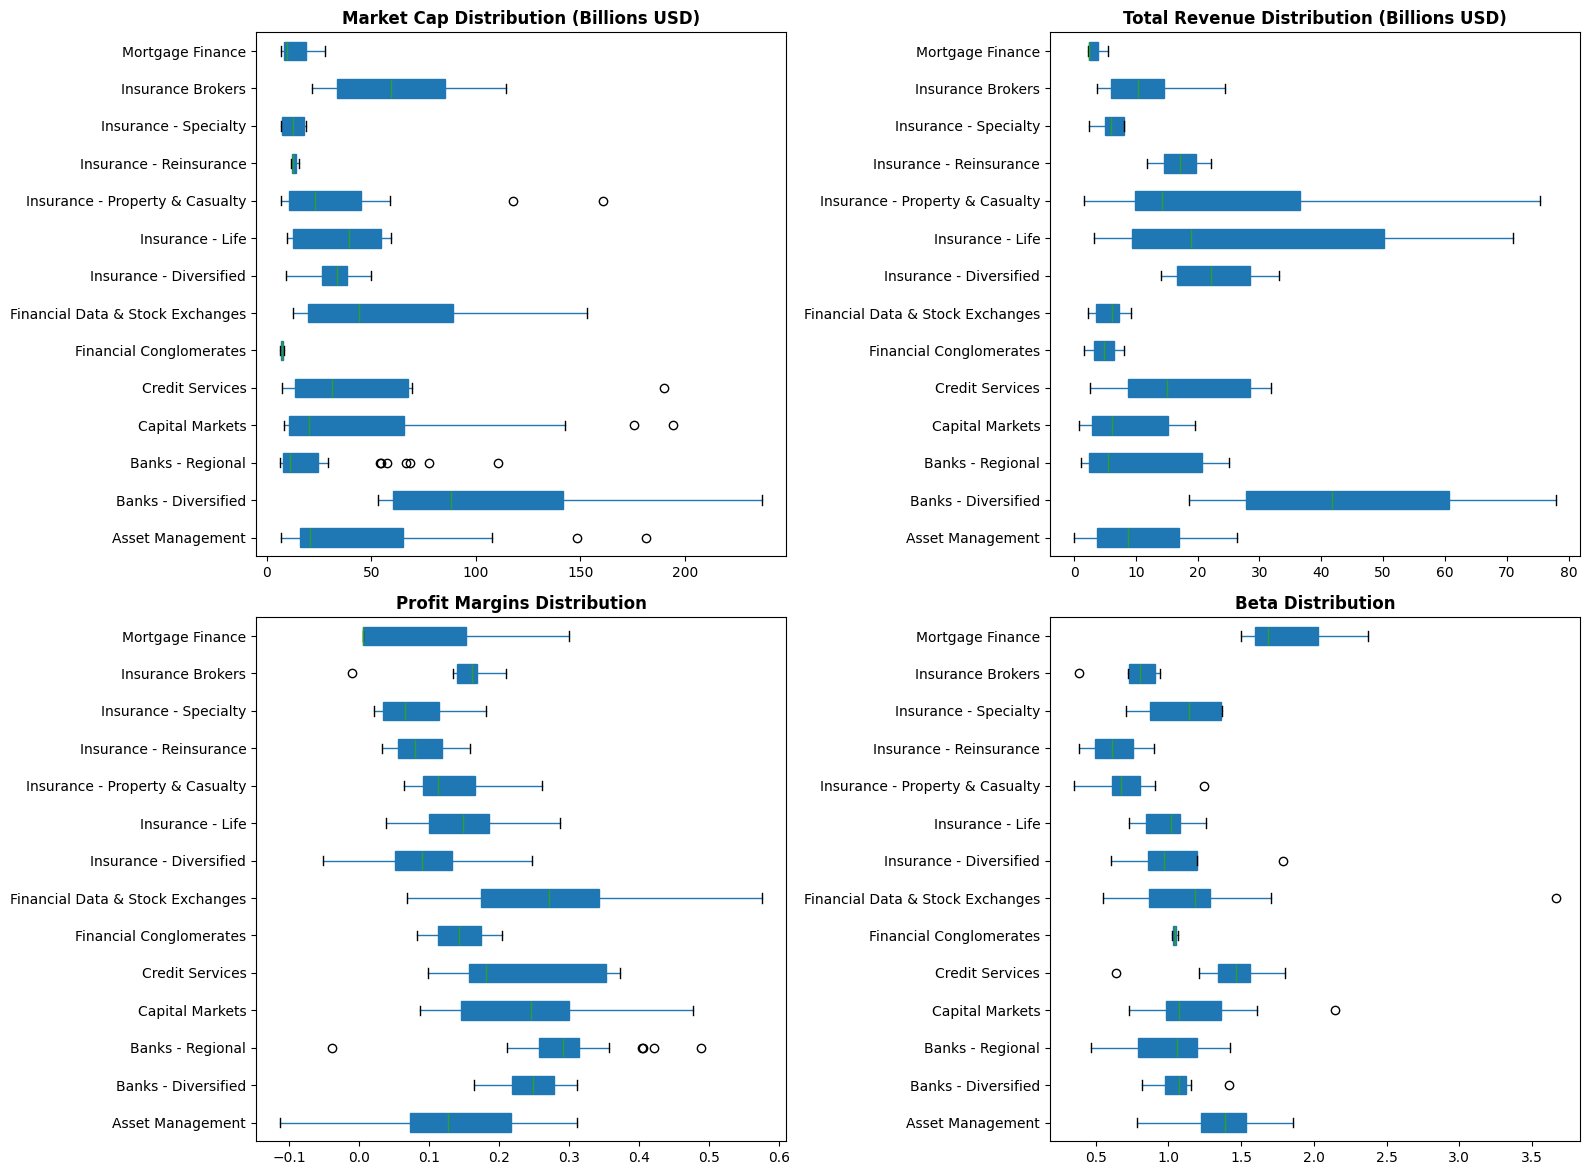

In [6]:
# --- ESERCIZIO 4: FULL DISTRIBUTIONS BY INDUSTRY (METODO INFALLIBILE) ---

# Let's create a copy of the data just to immediately divide Market Cap and Revenue by 1 billion
df_plot = df_no_outliers.copy()
df_plot['market_cap'] = df_plot['market_cap'] / 1e9
df_plot['total_revenue'] = df_plot['total_revenue'] / 1e9

# Let's create the 2x2 grid
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))

# 1. Market Cap
df_plot.boxplot(column='market_cap', by='industry', ax=axes[0, 0], vert=False, grid=False, patch_artist=True)
axes[0, 0].set_title('Market Cap Distribution (Billions USD)', fontweight='bold')
axes[0, 0].set_xlabel('')
axes[0, 0].set_ylabel('')

# 2. Total Revenue
df_plot.boxplot(column='total_revenue', by='industry', ax=axes[0, 1], vert=False, grid=False, patch_artist=True, showfliers=False)  #i add showfliers=False to hide outliers, make the graph automatically zoom in on the boxes.
axes[0, 1].set_title('Total Revenue Distribution (Billions USD)', fontweight='bold')
axes[0, 1].set_xlabel('')
axes[0, 1].set_ylabel('')

# 3. Profit Margins
df_plot.boxplot(column='profit_margins', by='industry', ax=axes[1, 0], vert=False, grid=False, patch_artist=True)
axes[1, 0].set_title('Profit Margins Distribution', fontweight='bold')
axes[1, 0].set_xlabel('')
axes[1, 0].set_ylabel('')

# 4. Beta
df_plot.boxplot(column='beta', by='industry', ax=axes[1, 1], vert=False, grid=False, patch_artist=True)
axes[1, 1].set_title('Beta Distribution', fontweight='bold')
axes[1, 1].set_xlabel('')
axes[1, 1].set_ylabel('')

# Final cleaning
plt.suptitle('') # Removes the automatic title that Pandas sets by default
plt.tight_layout()

# Let's show the graph!
plt.show()

ESERCIZIO 5: JUSTIFICATION AND FILTER

I chose these four industries for the following reasons:
1. Financial Data & Stock Exchanges: High efficiency (low revenue vs. high margins).
2. Mortgage Finance: High risk/volatility (high beta) despite small size.
3. Banks - Diversified: High variability in size (wide boxes for Cap/Revenue)
but high consistency in returns (narrow boxes for Margins/Beta).
4. Insurance - Life: Strong disparity in revenue between companies but homogeneous market risk.

In [7]:
# 1. Let's create a list with the exact names of the chosen industries
selected_industries = [
    'Financial Data & Stock Exchanges',
    'Mortgage Finance',
    'Banks - Diversified',
    'Insurance - Life'
]

# 2. I filter the dataset using .isin()
df_focus = df_no_outliers[df_no_outliers['industry'].isin(selected_industries)]

# 3. Let's print how many companies we have left for confirmation
print(f"Aziende prima del filtro: {len(df_no_outliers)}")
print(f"Aziende dopo il filtro: {len(df_focus)}")

# Let's preview our new mini-dataset
df_focus.head()

Aziende prima del filtro: 145
Aziende dopo il filtro: 29


,symbol,company_name,sector,industry,market_cap,enterprise_value,current_price,previous_close,fifty_two_week_high,fifty_two_week_low,...,payout_ratio,average_volume,short_ratio,exchange,exchange_short_name,country,is_etf,is_fund,is_actively_trading,timestamp
36,WFC,Wells Fargo & Company,Financial Services,Banks - Diversified,236789383168,179842285568,72.519997,72.519997,81.500000,50.150002,...,0.2793,15647053,2.03,NYQ,NYQ,United States,0,0,1,2025-03-22 04:50:29
64,RY,Royal Bank Of Canada,Financial Services,Banks - Diversified,160726958080,18446743953848131584,113.599998,113.809998,128.050003,95.839996,...,0.4638,1168233,5.49,NYQ,NYQ,Canada,0,0,1,2025-03-22 04:50:46
67,SPGI,S&P Global Inc.,Financial Services,Financial Data & Stock Exchanges,153247465472,167952465920,497.880005,497.200012,545.390015,407.690002,...,0.2947,1356543,2.67,NYQ,NYQ,United States,0,0,1,2025-03-22 04:50:50
79,C,"Citigroup, Inc.",Financial Services,Banks - Diversified,135477886976,15625838592,71.980003,71.820000,84.739998,53.509998,...,0.3664,15289683,2.51,NYQ,NYQ,United States,0,0,1,2025-03-22 04:50:55
107,TD,Toronto Dominion Bank (The),Financial Services,Banks - Diversified,104969248768,18446744035028250624,59.529999,59.900002,64.910004,51.250000,...,0.8708,2216125,5.40,NYQ,NYQ,Canada,0,0,1,2025-03-22 04:51:22


ESERCIZIO 6: BUBBLE CHART & QUADRANTS ANALYSIS

Documentation of Encodings:
1. X-Axis (market_cap): Represents the market valuation/size of the company. 
   I chose this to test the "Too Big to Fail" hypothesis.
2. Y-Axis (beta): Represents the market risk and volatility. Paired with the X-axis, 
   it reveals if larger companies are inherently more stable than smaller ones.
3. Bubble Size (total_revenue): Represents the actual volume of business. 
   This adds a layer of depth, showing if high market caps are actually backed by massive revenues.
4. Bubble Color (industry): Categorizes the bubbles by our 4 selected industries 
   to identify cluster patterns and sector behaviors.

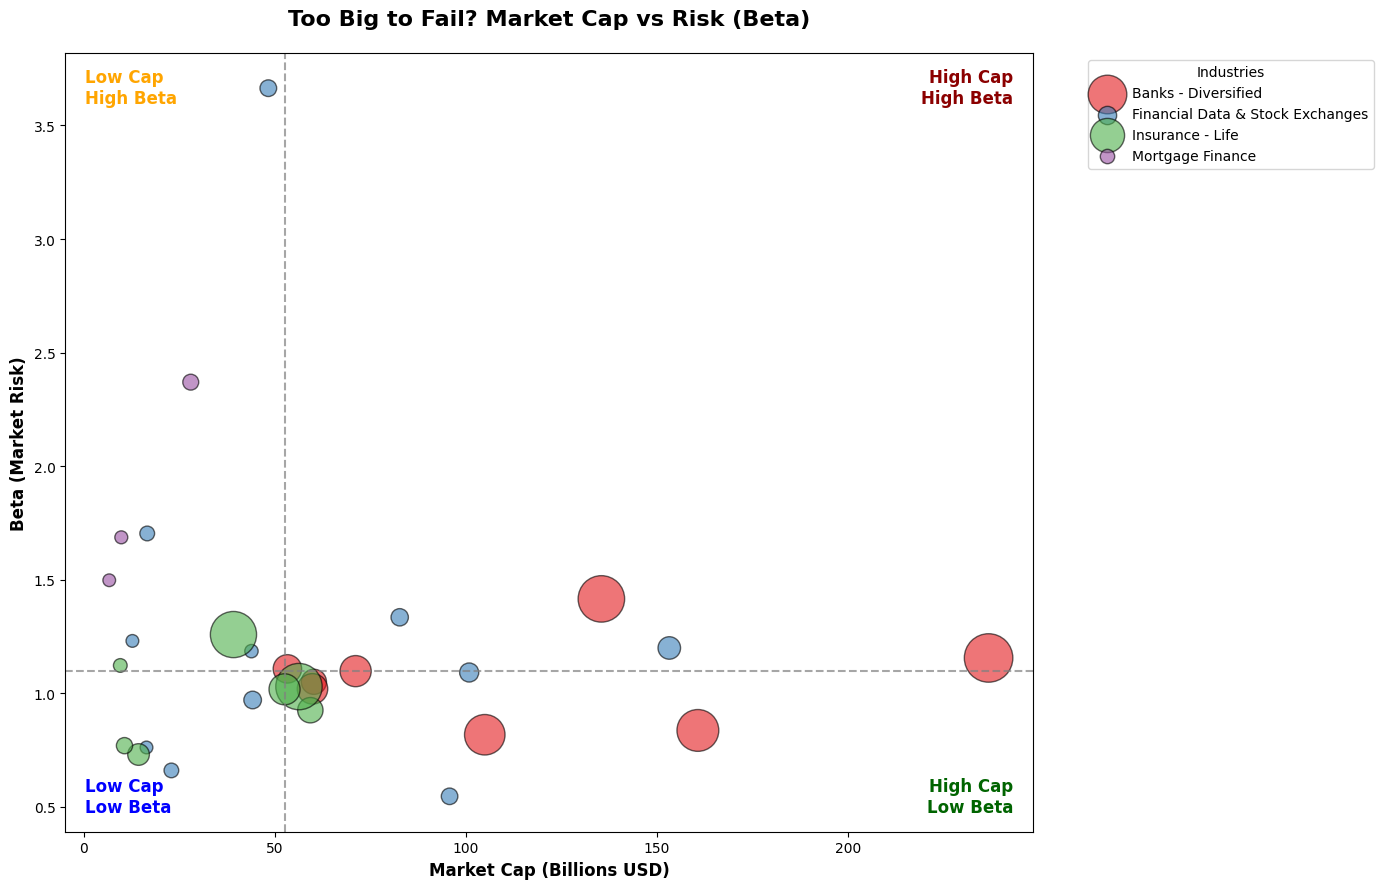

In [8]:
# Let's create a copy and divide the money by 1 billion, so the numbers on the axis are readable
df_plot = df_focus.copy()
df_plot['market_cap'] = df_plot['market_cap'] / 1e9
df_plot['total_revenue'] = df_plot['total_revenue'] / 1e9

# Let's set up the giant canvas
plt.figure(figsize=(14, 9))

# Let's find the medians to draw the cross of the quadrants
centro_x = df_plot['market_cap'].median()
centro_y = df_plot['beta'].median()

# List of our 4 industries and 4 colors to use
industrie = df_plot['industry'].unique()
colori = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3'] # Red, Blue, Green, Purple

# Let's draw the Bubble Chart using matplotlib (create a group for each industry)
for i, industria in enumerate(industrie):
    dati_industria = df_plot[df_plot['industry'] == industria]
    
    # Let's calculate the size of the bubble:
    # We multiply the revenue to make it visible, and add a base (+50)
 # so that companies with almost zero revenue don't become invisible.
    
    dimensione_bolle = (dati_industria['total_revenue'] * 15) + 50
    
    plt.scatter(
        x=dati_industria['market_cap'],
        y=dati_industria['beta'],
        s=dimensione_bolle,
        color=colori[i],
        alpha=0.6,
        edgecolors='black',
        label=industria
    )

# We draw the cross to create the 4 quadrants
plt.axvline(centro_x, color='grey', linestyle='--', alpha=0.7)
plt.axhline(centro_y, color='grey', linestyle='--', alpha=0.7)

# Writings at the 4 corners (Using the "absolute" screen coordinates from 0 to 1)
ax = plt.gca()

# Quadrant 1: Top Right (Large and Risky)
ax.text(0.98, 0.98, 'High Cap\nHigh Beta', transform=ax.transAxes, 
        color='darkred', fontsize=12, fontweight='bold', ha='right', va='top')

# Quadrant 2: Bottom Right (The Armored Giants / Safe)
ax.text(0.98, 0.02, 'High Cap\nLow Beta', transform=ax.transAxes, 
        color='darkgreen', fontsize=12, fontweight='bold', ha='right', va='bottom')

# Quadrant 3: Top Left (Small and Reckless)
ax.text(0.02, 0.98, 'Low Cap\nHigh Beta', transform=ax.transAxes, 
        color='orange', fontsize=12, fontweight='bold', ha='left', va='top')

# Quadrant 4: Bottom Left (Small and Stable)
ax.text(0.02, 0.02, 'Low Cap\nLow Beta', transform=ax.transAxes, 
        color='blue', fontsize=12, fontweight='bold', ha='left', va='bottom')

# Final embellishments
plt.title('Too Big to Fail? Market Cap vs Risk (Beta)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Market Cap (Billions USD)', fontsize=12, fontweight='bold')
plt.ylabel('Beta (Market Risk)', fontsize=12, fontweight='bold')

# Let's move the legend off the chart so as not to cover the bubbles
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Industries")
plt.tight_layout()

# Let's show the clean graph
plt.show()